In [1]:
# Cell 0: Complete Setup - Run this FIRST every time

import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

np.random.seed(42)

# ── Project Paths ──────────────────────────────────────
BASE        = "D:/Projects/Harsh_Mini_Project/medical_xray_project"
IMG_DIR     = f"{BASE}/data/images"
MODELS      = f"{BASE}/models"
PLOTS       = f"{BASE}/outputs/plots"
RESULTS     = f"{BASE}/outputs/results"
DB_PATH     = f"{BASE}/database/xray_metadata.db"

# ── Hyperparameters ────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16
AUTOTUNE    = tf.data.AUTOTUNE
BIAS_THRESHOLD = 0.05  # 5% gap = bias detected

# ── Load all CSVs ──────────────────────────────────────
metadata_df = pd.read_csv(
    f"{RESULTS}/processed_metadata.csv",
    encoding='utf-8')
test_df     = pd.read_csv(
    f"{RESULTS}/test.csv",
    encoding='utf-8')
pred_df     = pd.read_csv(
    f"{RESULTS}/test_predictions.csv",
    encoding='utf-8')

# ── Load test metrics ──────────────────────────────────
with open(f"{RESULTS}/test_metrics.json",
          'r', encoding='utf-8') as f:
    test_metrics = json.load(f)

print("=" * 50)
print("   CELL 0: SETUP COMPLETE")
print("=" * 50)
print(f"✅ metadata_df  : {len(metadata_df):,} rows")
print(f"✅ test_df      : {len(test_df):,} rows")
print(f"✅ pred_df      : {len(pred_df):,} rows")
print()
print(f"✅ Overall test metrics:")
print(f"   Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"   AUC       : {test_metrics['test_auc']:.4f}")
print(f"   F1 Score  : {test_metrics['f1_score']:.4f}")
print()
print(f"✅ Bias threshold : {BIAS_THRESHOLD*100:.0f}%")
print(f"   Gap > 5%  → BIAS DETECTED ⚠️")
print(f"   Gap ≤ 5%  → MINIMAL BIAS ✅")
print()
print(f"   pred_df columns:")
print(f"   {pred_df.columns.tolist()}")
print("=" * 50)
print("✅ Cell 0 complete - Ready to proceed")

   CELL 0: SETUP COMPLETE
✅ metadata_df  : 5,840 rows
✅ test_df      : 876 rows
✅ pred_df      : 876 rows

✅ Overall test metrics:
   Accuracy  : 0.9737
   AUC       : 0.9966
   F1 Score  : 0.9819

✅ Bias threshold : 5%
   Gap > 5%  → BIAS DETECTED ⚠️
   Gap ≤ 5%  → MINIMAL BIAS ✅

   pred_df columns:
   ['image_index', 'patient_id', 'age', 'gender', 'age_group', 'true_label', 'predicted', 'confidence', 'label_name', 'correct', 'predicted_name']
✅ Cell 0 complete - Ready to proceed


In [2]:
# Cell 1: Define function to calculate bias metrics

print("=" * 50)
print("   CELL 1: BIAS METRICS FUNCTION")
print("=" * 50)

def calculate_group_metrics(df, group_col,
                             group_val):
    """
    Calculate all 5 metrics for a specific group.
    
    Args:
        df        : predictions DataFrame
        group_col : column name (gender/age_group)
        group_val : group value (M/F/Young/Middle/Old)
    
    Returns:
        dict with all metrics
    """
    # Filter to this group
    subset = df[df[group_col] == group_val].copy()
    
    if len(subset) == 0:
        return None
    
    y_true = subset['true_label'].values
    y_pred = subset['predicted'].values
    y_prob = subset['confidence'].values
    
    # Calculate all 5 metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred,
                           zero_division=0)
    rec  = recall_score(y_true, y_pred,
                        zero_division=0)
    f1   = f1_score(y_true, y_pred,
                    zero_division=0)
    
    # AUC needs both classes present
    try:
        auc_score = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc_score = 0.0
    
    return {
        'group'    : group_val,
        'samples'  : len(subset),
        'correct'  : int(subset['correct'].sum()),
        'accuracy' : round(acc,  4),
        'precision': round(prec, 4),
        'recall'   : round(rec,  4),
        'f1_score' : round(f1,   4),
        'auc'      : round(auc_score, 4),
    }


def detect_bias(metrics_list, metric='accuracy'):
    """
    Detect bias by checking max gap between groups.
    Returns gap value and verdict.
    """
    values = [m[metric] for m in metrics_list
              if m is not None]
    gap    = max(values) - min(values)
    best   = max(metrics_list,
                 key=lambda x: x[metric])
    worst  = min(metrics_list,
                 key=lambda x: x[metric])

    if gap > BIAS_THRESHOLD:
        verdict = "⚠️  BIAS DETECTED"
    else:
        verdict = "✅ MINIMAL BIAS"

    return {
        'gap'    : round(gap, 4),
        'verdict': verdict,
        'best'   : best['group'],
        'worst'  : worst['group'],
        'best_val' : best[metric],
        'worst_val': worst[metric],
    }


# ── Test function on one group ─────────────────────────
test_result = calculate_group_metrics(
    pred_df, 'gender', 'M')

print(f"✅ calculate_group_metrics() defined")
print(f"✅ detect_bias() defined")
print()
print(f"   Test on Male group:")
for k, v in test_result.items():
    print(f"   {k:<12} : {v}")

print("=" * 50)
print("✅ Cell 1 complete")

   CELL 1: BIAS METRICS FUNCTION
✅ calculate_group_metrics() defined
✅ detect_bias() defined

   Test on Male group:
   group        : M
   samples      : 483
   correct      : 473
   accuracy     : 0.9793
   precision    : 0.9971
   recall       : 0.9744
   f1_score     : 0.9856
   auc          : 0.9991
✅ Cell 1 complete


In [3]:
# Cell 2: Gender bias analysis

print("=" * 50)
print("   CELL 2: GENDER BIAS ANALYSIS")
print("=" * 50)

# ── Calculate metrics for each gender ─────────────────
gender_results = []
for gender in ['M', 'F']:
    result = calculate_group_metrics(
        pred_df, 'gender', gender)
    gender_results.append(result)
    label = 'Male' if gender == 'M' else 'Female'
    print(f"✅ {label} metrics calculated "
          f"({result['samples']} samples)")

print()

# ── Build gender bias DataFrame ────────────────────────
bias_gender_df = pd.DataFrame(gender_results)
bias_gender_df['gender_label'] = \
    bias_gender_df['group'].map(
        {'M': 'Male', 'F': 'Female'})

# ── Print results table ────────────────────────────────
print(f"   Gender Bias Analysis Table:")
print(f"   {'Metric':<12} {'Male':>10} "
      f"{'Female':>10} {'Gap':>10}")
print(f"   {'─'*12} {'─'*10} {'─'*10} {'─'*10}")

metrics_to_show = ['samples', 'accuracy',
                   'precision', 'recall',
                   'f1_score', 'auc']

for metric in metrics_to_show:
    male_val   = gender_results[0][metric]
    female_val = gender_results[1][metric]

    if metric == 'samples':
        print(f"   {metric:<12} {male_val:>10} "
              f"{female_val:>10} {'─':>10}")
    else:
        gap    = abs(male_val - female_val)
        marker = " ⚠️" if gap > BIAS_THRESHOLD else " ✅"
        print(f"   {metric:<12} {male_val:>10.4f} "
              f"{female_val:>10.4f} "
              f"{gap:>10.4f}{marker}")

print()

# ── Detect bias ────────────────────────────────────────
bias_info = detect_bias(gender_results, 'accuracy')
print(f"   Bias Detection (Accuracy):")
print(f"   Gap         : {bias_info['gap']*100:.2f}%")
print(f"   Verdict     : {bias_info['verdict']}")
print(f"   Best group  : {bias_info['best']} "
      f"({bias_info['best_val']*100:.2f}%)")
print(f"   Worst group : {bias_info['worst']} "
      f"({bias_info['worst_val']*100:.2f}%)")

print()

# ── Save bias gender CSV ───────────────────────────────
save_cols = ['group', 'samples', 'accuracy',
             'precision', 'recall',
             'f1_score', 'auc']
bias_gender_save = bias_gender_df[save_cols].copy()
bias_gender_save.columns = ['gender', 'samples',
                             'accuracy', 'precision',
                             'recall', 'f1_score', 'auc']

save_path = f"{RESULTS}/bias_gender.csv"
bias_gender_save.to_csv(save_path, index=False,
                        encoding='utf-8')
print(f"✅ Saved : {save_path}")
print("=" * 50)
print("✅ Cell 2 complete")

   CELL 2: GENDER BIAS ANALYSIS
✅ Male metrics calculated (483 samples)
✅ Female metrics calculated (393 samples)

   Gender Bias Analysis Table:
   Metric             Male     Female        Gap
   ──────────── ────────── ────────── ──────────
   samples             483        393          ─
   accuracy         0.9793     0.9669     0.0124 ✅
   precision        0.9971     0.9791     0.0180 ✅
   recall           0.9744     0.9757     0.0013 ✅
   f1_score         0.9856     0.9774     0.0082 ✅
   auc              0.9991     0.9938     0.0053 ✅

   Bias Detection (Accuracy):
   Gap         : 1.24%
   Verdict     : ✅ MINIMAL BIAS
   Best group  : M (97.93%)
   Worst group : F (96.69%)

✅ Saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results/bias_gender.csv
✅ Cell 2 complete


In [4]:
# Cell 3: Age group bias analysis

print("=" * 50)
print("   CELL 3: AGE GROUP BIAS ANALYSIS")
print("=" * 50)

# ── Calculate metrics for each age group ──────────────
age_groups     = ['Young', 'Middle', 'Old']
age_results    = []

for age_grp in age_groups:
    result = calculate_group_metrics(
        pred_df, 'age_group', age_grp)
    age_results.append(result)
    print(f"✅ {age_grp:<8} metrics calculated "
          f"({result['samples']} samples)")

print()

# ── Build age bias DataFrame ───────────────────────────
bias_age_df = pd.DataFrame(age_results)

# ── Print results table ────────────────────────────────
print(f"   Age Group Bias Analysis Table:")
print(f"   {'Metric':<12} {'Young':>10} "
      f"{'Middle':>10} {'Old':>10} {'Gap':>10}")
print(f"   {'─'*12} {'─'*10} {'─'*10} "
      f"{'─'*10} {'─'*10}")

metrics_to_show = ['samples', 'accuracy',
                   'precision', 'recall',
                   'f1_score', 'auc']

for metric in metrics_to_show:
    young_val  = age_results[0][metric]
    middle_val = age_results[1][metric]
    old_val    = age_results[2][metric]

    if metric == 'samples':
        print(f"   {metric:<12} {young_val:>10} "
              f"{middle_val:>10} {old_val:>10} "
              f"{'─':>10}")
    else:
        gap    = max(young_val, middle_val, old_val) - \
                 min(young_val, middle_val, old_val)
        marker = " ⚠️" if gap > BIAS_THRESHOLD \
                 else " ✅"
        print(f"   {metric:<12} {young_val:>10.4f} "
              f"{middle_val:>10.4f} {old_val:>10.4f} "
              f"{gap:>10.4f}{marker}")

print()

# ── Detect bias ────────────────────────────────────────
bias_info = detect_bias(age_results, 'accuracy')
print(f"   Bias Detection (Accuracy):")
print(f"   Gap         : {bias_info['gap']*100:.2f}%")
print(f"   Verdict     : {bias_info['verdict']}")
print(f"   Best group  : {bias_info['best']} "
      f"({bias_info['best_val']*100:.2f}%)")
print(f"   Worst group : {bias_info['worst']} "
      f"({bias_info['worst_val']*100:.2f}%)")

print()

# ── Save bias age CSV ──────────────────────────────────
save_cols = ['group', 'samples', 'accuracy',
             'precision', 'recall',
             'f1_score', 'auc']
bias_age_save = bias_age_df[save_cols].copy()
bias_age_save.columns = ['age_group', 'samples',
                          'accuracy', 'precision',
                          'recall', 'f1_score', 'auc']

save_path = f"{RESULTS}/bias_age_group.csv"
bias_age_save.to_csv(save_path, index=False,
                     encoding='utf-8')
print(f"✅ Saved : {save_path}")
print("=" * 50)
print("✅ Cell 3 complete")

   CELL 3: AGE GROUP BIAS ANALYSIS
✅ Young    metrics calculated (266 samples)
✅ Middle   metrics calculated (398 samples)
✅ Old      metrics calculated (212 samples)

   Age Group Bias Analysis Table:
   Metric            Young     Middle        Old        Gap
   ──────────── ────────── ────────── ────────── ──────────
   samples             266        398        212          ─
   accuracy         0.9699     0.9799     0.9670     0.0129 ✅
   precision        0.9833     0.9966     0.9806     0.0160 ✅
   recall           0.9725     0.9768     0.9744     0.0043 ✅
   f1_score         0.9779     0.9866     0.9775     0.0091 ✅
   auc              0.9970     0.9983     0.9927     0.0056 ✅

   Bias Detection (Accuracy):
   Gap         : 1.29%
   Verdict     : ✅ MINIMAL BIAS
   Best group  : Middle (97.99%)
   Worst group : Old (96.70%)

✅ Saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results/bias_age_group.csv
✅ Cell 3 complete


In [5]:
# Cell 4: Combined Gender x Age group analysis

print("=" * 50)
print("   CELL 4: COMBINED GENDER x AGE ANALYSIS")
print("=" * 50)

age_groups = ['Young', 'Middle', 'Old']
genders    = ['M', 'F']
combined_results = []

# ── Calculate metrics for all 6 combinations ──────────
for gender in genders:
    for age_grp in age_groups:
        subset = pred_df[
            (pred_df['gender']    == gender) &
            (pred_df['age_group'] == age_grp)
        ].copy()

        if len(subset) == 0:
            continue

        y_true = subset['true_label'].values
        y_pred = subset['predicted'].values
        y_prob = subset['confidence'].values

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred,
                               zero_division=0)
        rec  = recall_score(y_true, y_pred,
                            zero_division=0)
        f1   = f1_score(y_true, y_pred,
                        zero_division=0)
        try:
            auc_score = roc_auc_score(y_true, y_prob)
        except ValueError:
            auc_score = 0.0

        g_label = 'Male' if gender == 'M' else 'Female'
        combined_results.append({
            'gender'    : gender,
            'gender_label': g_label,
            'age_group' : age_grp,
            'samples'   : len(subset),
            'accuracy'  : round(acc,  4),
            'precision' : round(prec, 4),
            'recall'    : round(rec,  4),
            'f1_score'  : round(f1,   4),
            'auc'       : round(auc_score, 4),
        })

# ── Print combined table ───────────────────────────────
print(f"   {'Group':<20} {'N':>6} {'Acc':>8} "
      f"{'Prec':>8} {'Rec':>8} {'F1':>8}")
print(f"   {'─'*20} {'─'*6} {'─'*8} "
      f"{'─'*8} {'─'*8} {'─'*8}")

for r in combined_results:
    group_label = f"{r['gender_label']}-{r['age_group']}"
    print(f"   {group_label:<20} {r['samples']:>6} "
          f"{r['accuracy']:>8.4f} "
          f"{r['precision']:>8.4f} "
          f"{r['recall']:>8.4f} "
          f"{r['f1_score']:>8.4f}")

print()

# ── Build accuracy pivot table ─────────────────────────
combined_df = pd.DataFrame(combined_results)

pivot_acc = combined_df.pivot(
    index   = 'gender_label',
    columns = 'age_group',
    values  = 'accuracy'
)[age_groups]

pivot_n = combined_df.pivot(
    index   = 'gender_label',
    columns = 'age_group',
    values  = 'samples'
)[age_groups]

print(f"   Accuracy Pivot Table (Gender x Age):")
print(pivot_acc.round(4).to_string())
print()
print(f"   Sample Count Pivot Table:")
print(pivot_n.to_string())

# ── Find best and worst combinations ──────────────────
best  = combined_df.loc[
    combined_df['accuracy'].idxmax()]
worst = combined_df.loc[
    combined_df['accuracy'].idxmin()]

print()
print(f"   Best combination  : "
      f"{best['gender_label']}-{best['age_group']} "
      f"({best['accuracy']*100:.2f}%)")
print(f"   Worst combination : "
      f"{worst['gender_label']}-{worst['age_group']} "
      f"({worst['accuracy']*100:.2f}%)")
print(f"   Overall gap       : "
      f"{(best['accuracy']-worst['accuracy'])*100:.2f}%")

# ── Save combined CSV ──────────────────────────────────
save_cols  = ['gender', 'age_group', 'samples',
              'accuracy', 'precision',
              'recall', 'f1_score', 'auc']
save_path  = f"{RESULTS}/bias_combined.csv"
combined_df[save_cols].to_csv(
    save_path, index=False, encoding='utf-8')

print()
print(f"✅ Saved : {save_path}")
print("=" * 50)
print("✅ Cell 4 complete")

   CELL 4: COMBINED GENDER x AGE ANALYSIS
   Group                     N      Acc     Prec      Rec       F1
   ──────────────────── ────── ──────── ──────── ──────── ────────
   Male-Young              149   0.9664   0.9895   0.9592   0.9741
   Male-Middle             210   0.9905   1.0000   0.9876   0.9938
   Male-Old                124   0.9758   1.0000   0.9677   0.9836
   Female-Young            117   0.9744   0.9765   0.9881   0.9822
   Female-Middle           188   0.9681   0.9927   0.9645   0.9784
   Female-Old               88   0.9545   0.9538   0.9841   0.9688

   Accuracy Pivot Table (Gender x Age):
age_group      Young  Middle     Old
gender_label                        
Female        0.9744  0.9681  0.9545
Male          0.9664  0.9905  0.9758

   Sample Count Pivot Table:
age_group     Young  Middle  Old
gender_label                    
Female          117     188   88
Male            149     210  124

   Best combination  : Male-Middle (99.05%)
   Worst combination : Fem

   CELL 5: GENDER BIAS VISUALIZATION


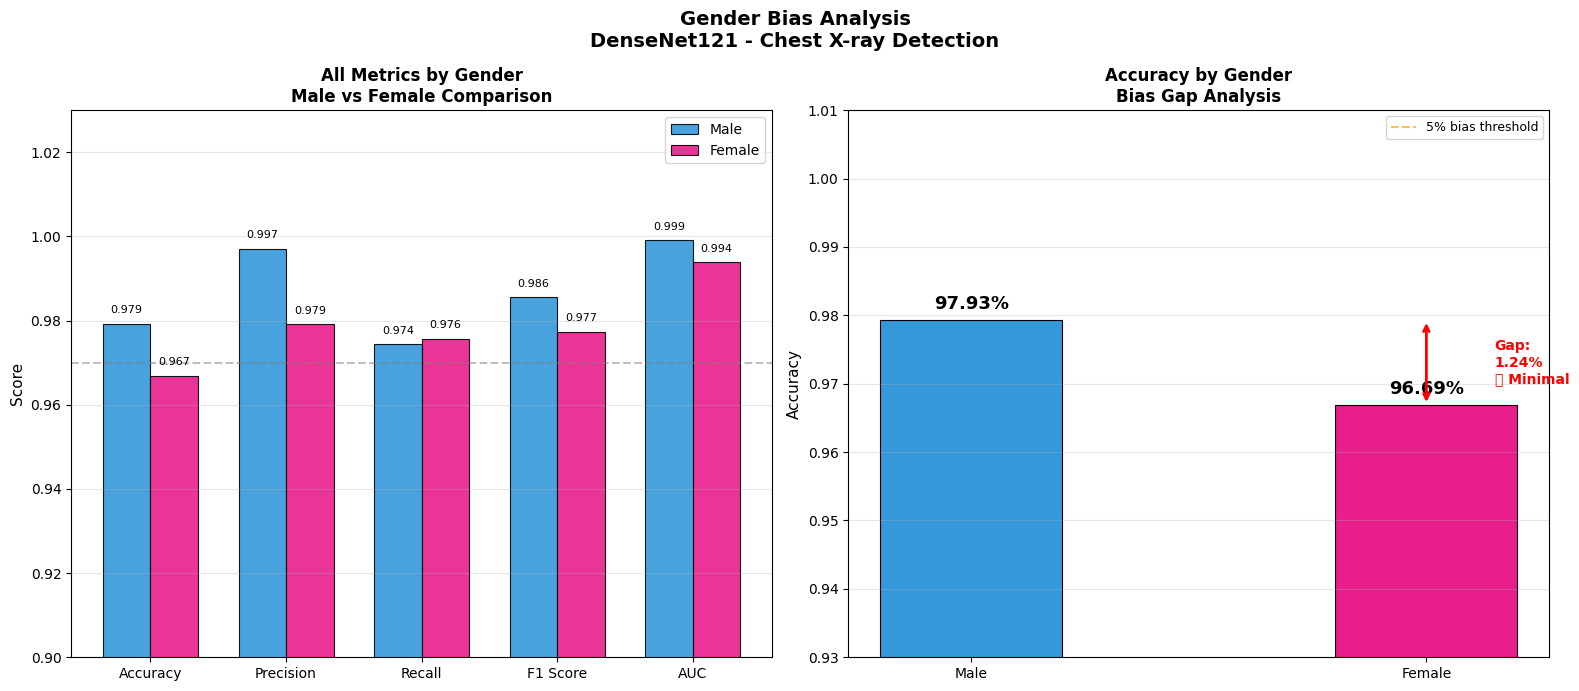

✅ Gender bias chart saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/bias_gender.png
   Gap    : 1.24%
   Verdict: ✅ MINIMAL BIAS
✅ Cell 5 complete


In [6]:
# Cell 5: Gender bias visualization

print("=" * 50)
print("   CELL 5: GENDER BIAS VISUALIZATION")
print("=" * 50)

# ── Load saved bias data ───────────────────────────────
bias_gender_df = pd.read_csv(
    f"{RESULTS}/bias_gender.csv",
    encoding='utf-8')

metrics     = ['accuracy', 'precision',
               'recall', 'f1_score', 'auc']
metric_lbls = ['Accuracy', 'Precision',
               'Recall', 'F1 Score', 'AUC']
colors      = {'M': '#3498db', 'F': '#e91e8c'}
g_labels    = {'M': 'Male', 'F': 'Female'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Chart 1: Grouped bar chart (all 5 metrics) ────────
x         = np.arange(len(metrics))
width     = 0.35
genders   = bias_gender_df['gender'].tolist()

bars_m = axes[0].bar(
    x - width/2,
    [bias_gender_df[bias_gender_df['gender']=='M']
     [m].values[0] for m in metrics],
    width, label='Male',
    color='#3498db', edgecolor='black',
    linewidth=0.8, alpha=0.9
)
bars_f = axes[0].bar(
    x + width/2,
    [bias_gender_df[bias_gender_df['gender']=='F']
     [m].values[0] for m in metrics],
    width, label='Female',
    color='#e91e8c', edgecolor='black',
    linewidth=0.8, alpha=0.9
)

# Add value labels on bars
for bar in bars_m:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        h + 0.002, f'{h:.3f}',
        ha='center', va='bottom', fontsize=8)

for bar in bars_f:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        h + 0.002, f'{h:.3f}',
        ha='center', va='bottom', fontsize=8)

axes[0].set_title(
    'All Metrics by Gender\n'
    'Male vs Female Comparison',
    fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_lbls, fontsize=10)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_ylim(0.90, 1.03)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0.97, color='gray',
                linestyle='--', alpha=0.5,
                label='Overall accuracy')

# ── Chart 2: Accuracy comparison with gap ─────────────
gender_names = ['Male', 'Female']
accuracies   = [
    bias_gender_df[bias_gender_df['gender']=='M']
    ['accuracy'].values[0],
    bias_gender_df[bias_gender_df['gender']=='F']
    ['accuracy'].values[0]
]
bar_colors = ['#3498db', '#e91e8c']

bars2 = axes[1].bar(gender_names, accuracies,
                    color=bar_colors,
                    edgecolor='black',
                    linewidth=0.8, width=0.4)

for bar, acc in zip(bars2, accuracies):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{acc*100:.2f}%',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold')

# Draw gap arrow
gap = abs(accuracies[0] - accuracies[1])
axes[1].annotate(
    '', xy=(1, min(accuracies)),
    xytext=(1, max(accuracies)),
    arrowprops=dict(
        arrowstyle='<->', color='red', lw=2))
axes[1].text(
    1.15, (accuracies[0]+accuracies[1])/2,
    f'Gap:\n{gap*100:.2f}%\n✅ Minimal',
    ha='left', va='center',
    fontsize=10, color='red',
    fontweight='bold')

axes[1].set_title(
    'Accuracy by Gender\nBias Gap Analysis',
    fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_ylim(0.93, 1.01)
axes[1].grid(axis='y', alpha=0.3)

# Threshold line
axes[1].axhline(
    y=min(accuracies) + BIAS_THRESHOLD,
    color='orange', linestyle='--',
    linewidth=1.5, alpha=0.7,
    label=f'5% bias threshold')
axes[1].legend(fontsize=9)

plt.suptitle(
    'Gender Bias Analysis\n'
    'DenseNet121 - Chest X-ray Detection',
    fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = f"{PLOTS}/bias_gender.png"
plt.savefig(save_path, dpi=150,
            bbox_inches='tight')
plt.show()

print(f"✅ Gender bias chart saved : {save_path}")
print(f"   Gap    : {gap*100:.2f}%")
print(f"   Verdict: ✅ MINIMAL BIAS")
print("=" * 50)
print("✅ Cell 5 complete")

   CELL 6: AGE GROUP BIAS VISUALIZATION


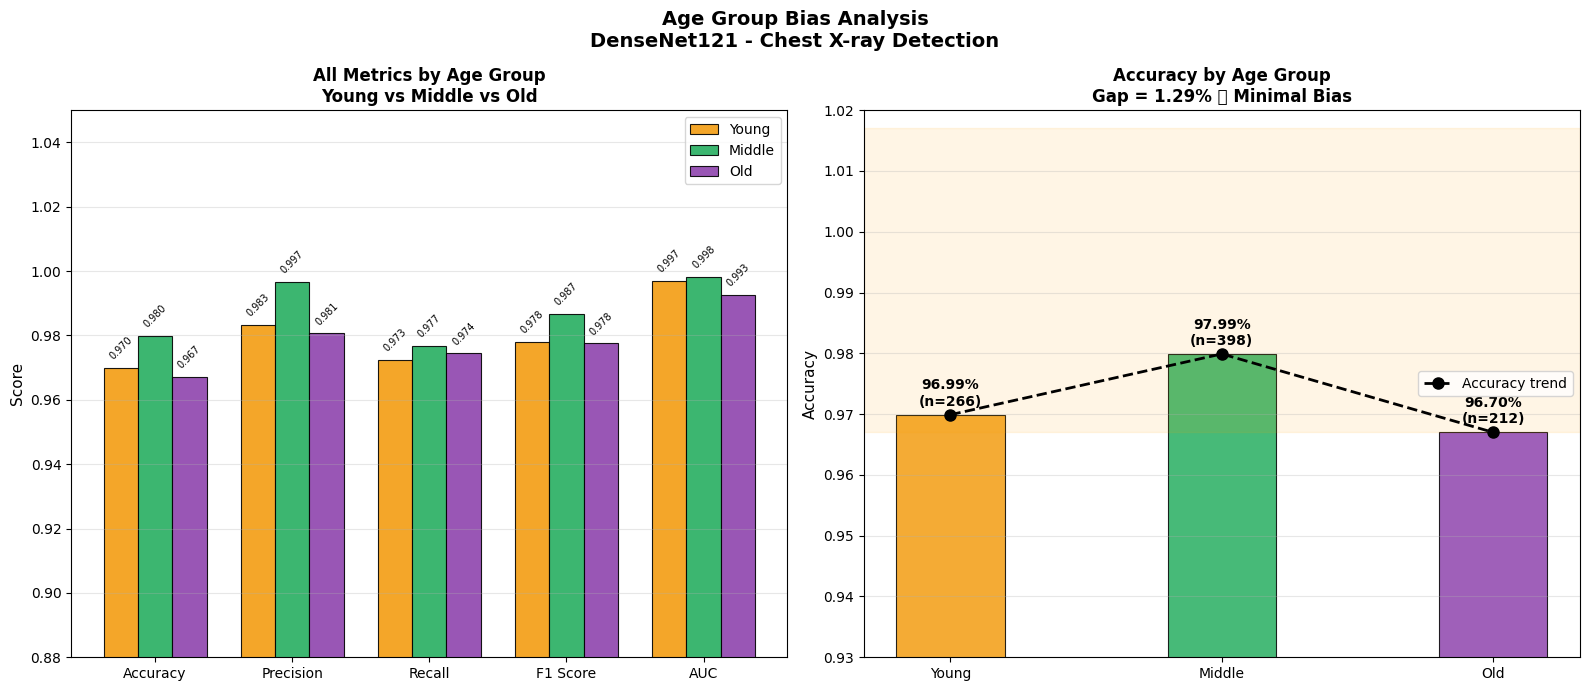

✅ Age group bias chart saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/bias_age_groups.png
   Best  : Middle  (97.99%)
   Worst : Old (96.70%)
   Gap   : 1.29%
   Verdict: ✅ MINIMAL BIAS
✅ Cell 6 complete


In [7]:
# Cell 6: Age group bias visualization

print("=" * 50)
print("   CELL 6: AGE GROUP BIAS VISUALIZATION")
print("=" * 50)

# ── Load saved bias data ───────────────────────────────
bias_age_df = pd.read_csv(
    f"{RESULTS}/bias_age_group.csv",
    encoding='utf-8')

age_groups  = ['Young', 'Middle', 'Old']
metrics     = ['accuracy', 'precision',
               'recall', 'f1_score', 'auc']
metric_lbls = ['Accuracy', 'Precision',
               'Recall', 'F1 Score', 'AUC']
age_colors  = ['#f39c12', '#27ae60', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Chart 1: Grouped bar chart (all 5 metrics) ────────
x     = np.arange(len(metrics))
width = 0.25

for idx, (age_grp, color) in enumerate(
        zip(age_groups, age_colors)):
    row    = bias_age_df[
        bias_age_df['age_group'] == age_grp
    ].iloc[0]
    values = [row[m] for m in metrics]
    offset = (idx - 1) * width

    bars = axes[0].bar(
        x + offset, values,
        width, label=age_grp,
        color=color, edgecolor='black',
        linewidth=0.8, alpha=0.9
    )
    for bar, val in zip(bars, values):
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=7, rotation=45)

axes[0].set_title(
    'All Metrics by Age Group\n'
    'Young vs Middle vs Old',
    fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_lbls, fontsize=10)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_ylim(0.88, 1.05)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ── Chart 2: Accuracy trend line ──────────────────────
accuracies = [
    bias_age_df[bias_age_df['age_group']==g]
    ['accuracy'].values[0]
    for g in age_groups
]
samples = [
    bias_age_df[bias_age_df['age_group']==g]
    ['samples'].values[0]
    for g in age_groups
]

# Bar chart with trend line
bars2 = axes[1].bar(
    age_groups, accuracies,
    color=age_colors, edgecolor='black',
    linewidth=0.8, alpha=0.85, width=0.4
)

# Add value labels
for bar, acc, n in zip(bars2, accuracies, samples):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{acc*100:.2f}%\n(n={n})',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold')

# Trend line
axes[1].plot(age_groups, accuracies,
             'ko--', linewidth=2,
             markersize=8, label='Accuracy trend')

# Gap annotation
gap = max(accuracies) - min(accuracies)
axes[1].set_title(
    f'Accuracy by Age Group\n'
    f'Gap = {gap*100:.2f}% ✅ Minimal Bias',
    fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_ylim(0.93, 1.02)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(fontsize=10)

# Threshold band
axes[1].axhspan(
    min(accuracies),
    min(accuracies) + BIAS_THRESHOLD,
    alpha=0.1, color='orange',
    label='5% threshold zone')

plt.suptitle(
    'Age Group Bias Analysis\n'
    'DenseNet121 - Chest X-ray Detection',
    fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = f"{PLOTS}/bias_age_groups.png"
plt.savefig(save_path, dpi=150,
            bbox_inches='tight')
plt.show()

# Print summary
gap = max(accuracies) - min(accuracies)
best_grp  = age_groups[accuracies.index(
            max(accuracies))]
worst_grp = age_groups[accuracies.index(
            min(accuracies))]

print(f"✅ Age group bias chart saved : {save_path}")
print(f"   Best  : {best_grp}  "
      f"({max(accuracies)*100:.2f}%)")
print(f"   Worst : {worst_grp} "
      f"({min(accuracies)*100:.2f}%)")
print(f"   Gap   : {gap*100:.2f}%")
print(f"   Verdict: ✅ MINIMAL BIAS")
print("=" * 50)
print("✅ Cell 6 complete")

   CELL 7: COMBINED BIAS HEATMAP


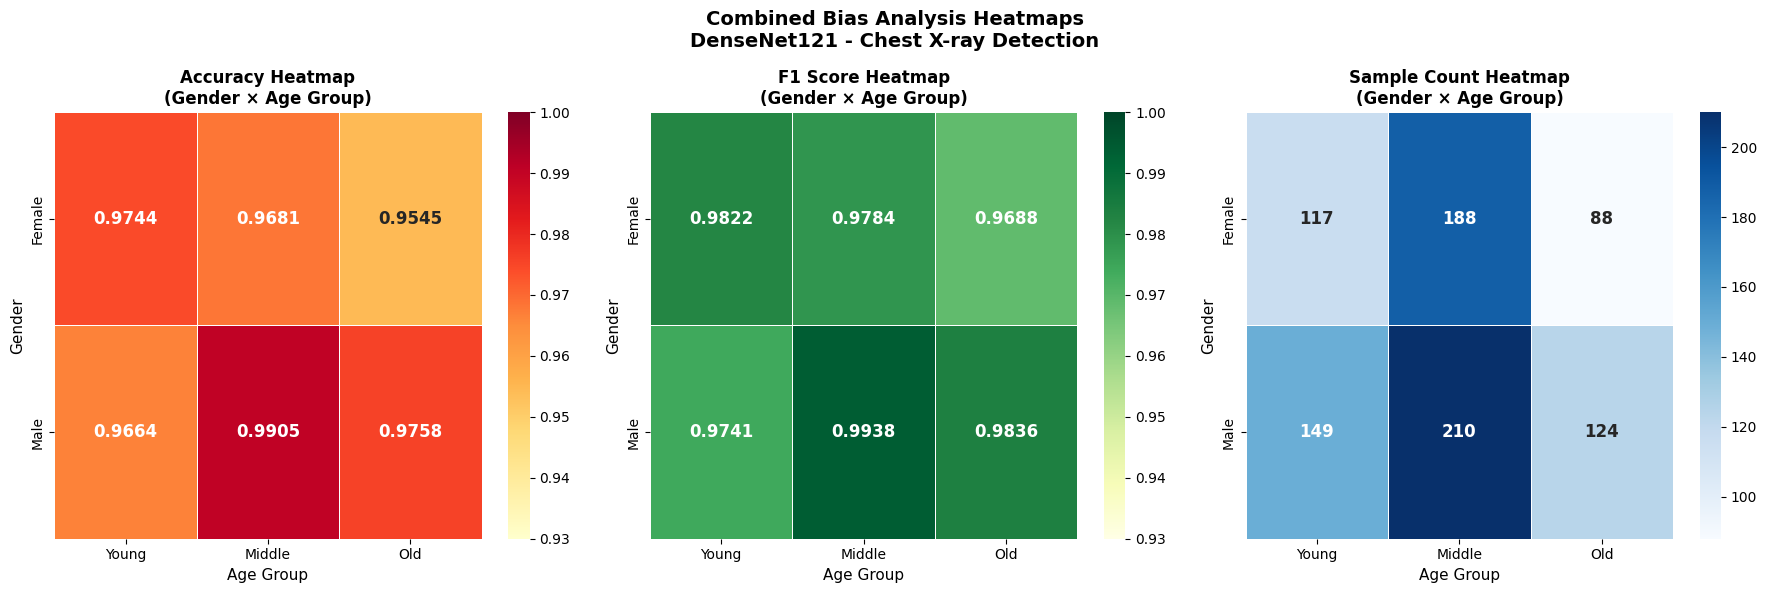

   Accuracy Heatmap Values:
age_group      Young  Middle     Old
gender_label                        
Female        0.9744  0.9681  0.9545
Male          0.9664  0.9905  0.9758

   F1 Score Heatmap Values:
age_group      Young  Middle     Old
gender_label                        
Female        0.9822  0.9784  0.9688
Male          0.9741  0.9938  0.9836

   Sample Counts:
age_group     Young  Middle  Old
gender_label                    
Female          117     188   88
Male            149     210  124

✅ Heatmap saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/bias_combined_heatmap.png
✅ Cell 7 complete


In [8]:
# Cell 7: Combined Gender x Age heatmap

print("=" * 50)
print("   CELL 7: COMBINED BIAS HEATMAP")
print("=" * 50)

# ── Load combined bias data ────────────────────────────
combined_df = pd.read_csv(
    f"{RESULTS}/bias_combined.csv",
    encoding='utf-8')

age_groups   = ['Young', 'Middle', 'Old']
gender_map   = {'M': 'Male', 'F': 'Female'}
combined_df['gender_label'] = \
    combined_df['gender'].map(gender_map)

# ── Build pivot tables ─────────────────────────────────
pivot_acc = combined_df.pivot(
    index   = 'gender_label',
    columns = 'age_group',
    values  = 'accuracy'
)[age_groups]

pivot_n = combined_df.pivot(
    index   = 'gender_label',
    columns = 'age_group',
    values  = 'samples'
)[age_groups]

pivot_f1 = combined_df.pivot(
    index   = 'gender_label',
    columns = 'age_group',
    values  = 'f1_score'
)[age_groups]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Heatmap 1: Accuracy ────────────────────────────────
sns.heatmap(
    pivot_acc,
    ax          = axes[0],
    annot       = True,
    fmt         = '.4f',
    cmap        = 'YlOrRd',
    vmin        = 0.93,
    vmax        = 1.00,
    linewidths  = 0.5,
    annot_kws   = {'size': 12, 'weight': 'bold'}
)
axes[0].set_title(
    'Accuracy Heatmap\n(Gender × Age Group)',
    fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age Group', fontsize=11)
axes[0].set_ylabel('Gender', fontsize=11)

# ── Heatmap 2: F1 Score ────────────────────────────────
sns.heatmap(
    pivot_f1,
    ax          = axes[1],
    annot       = True,
    fmt         = '.4f',
    cmap        = 'YlGn',
    vmin        = 0.93,
    vmax        = 1.00,
    linewidths  = 0.5,
    annot_kws   = {'size': 12, 'weight': 'bold'}
)
axes[1].set_title(
    'F1 Score Heatmap\n(Gender × Age Group)',
    fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group', fontsize=11)
axes[1].set_ylabel('Gender', fontsize=11)

# ── Heatmap 3: Sample counts ───────────────────────────
sns.heatmap(
    pivot_n,
    ax          = axes[2],
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    linewidths  = 0.5,
    annot_kws   = {'size': 12, 'weight': 'bold'}
)
axes[2].set_title(
    'Sample Count Heatmap\n(Gender × Age Group)',
    fontsize=12, fontweight='bold')
axes[2].set_xlabel('Age Group', fontsize=11)
axes[2].set_ylabel('Gender', fontsize=11)

plt.suptitle(
    'Combined Bias Analysis Heatmaps\n'
    'DenseNet121 - Chest X-ray Detection',
    fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = f"{PLOTS}/bias_combined_heatmap.png"
plt.savefig(save_path, dpi=150,
            bbox_inches='tight')
plt.show()

# ── Print heatmap values ───────────────────────────────
print(f"   Accuracy Heatmap Values:")
print(pivot_acc.round(4).to_string())
print()
print(f"   F1 Score Heatmap Values:")
print(pivot_f1.round(4).to_string())
print()
print(f"   Sample Counts:")
print(pivot_n.to_string())
print()
print(f"✅ Heatmap saved : {save_path}")
print("=" * 50)
print("✅ Cell 7 complete")

In [9]:
# Cell 8: Bias gap summary and research insights

print("=" * 50)
print("   CELL 8: BIAS GAP SUMMARY")
print("=" * 50)

# ── Load all bias data ─────────────────────────────────
bias_gender_df  = pd.read_csv(
    f"{RESULTS}/bias_gender.csv",
    encoding='utf-8')
bias_age_df     = pd.read_csv(
    f"{RESULTS}/bias_age_group.csv",
    encoding='utf-8')
combined_df     = pd.read_csv(
    f"{RESULTS}/bias_combined.csv",
    encoding='utf-8')

# ── Calculate all gaps ─────────────────────────────────
# Gender gaps
gender_acc_gap  = abs(
    bias_gender_df[bias_gender_df['gender']=='M']
    ['accuracy'].values[0] -
    bias_gender_df[bias_gender_df['gender']=='F']
    ['accuracy'].values[0]
)
gender_rec_gap  = abs(
    bias_gender_df[bias_gender_df['gender']=='M']
    ['recall'].values[0] -
    bias_gender_df[bias_gender_df['gender']=='F']
    ['recall'].values[0]
)

# Age gaps
age_accs        = bias_age_df['accuracy'].values
age_acc_gap     = max(age_accs) - min(age_accs)
age_recs        = bias_age_df['recall'].values
age_rec_gap     = max(age_recs) - min(age_recs)

# Combined gap
comb_accs       = combined_df['accuracy'].values
comb_gap        = max(comb_accs) - min(comb_accs)

best_comb  = combined_df.loc[
    combined_df['accuracy'].idxmax()]
worst_comb = combined_df.loc[
    combined_df['accuracy'].idxmin()]

gender_map = {'M': 'Male', 'F': 'Female'}
best_gender_row  = bias_gender_df.loc[
    bias_gender_df['accuracy'].idxmax()]
worst_gender_row = bias_gender_df.loc[
    bias_gender_df['accuracy'].idxmin()]
best_age_row  = bias_age_df.loc[
    bias_age_df['accuracy'].idxmax()]
worst_age_row = bias_age_df.loc[
    bias_age_df['accuracy'].idxmin()]

# ── Print research summary ─────────────────────────────
summary = f"""
╔══════════════════════════════════════════════════════╗
║         BIAS ANALYSIS SUMMARY - RESEARCH READY      ║
╚══════════════════════════════════════════════════════╝

PROJECT : Medical X-ray Anomaly Detection
MODEL   : DenseNet121 Transfer Learning
DATASET : Kaggle Chest X-ray (5,840 images)
BIAS THRESHOLD : 5% accuracy gap

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OVERALL MODEL PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy  : {test_metrics['accuracy']*100:.2f}%
  AUC       : {test_metrics['test_auc']:.4f}
  Precision : {test_metrics['precision']*100:.2f}%
  Recall    : {test_metrics['recall']*100:.2f}%
  F1 Score  : {test_metrics['f1_score']*100:.2f}%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GENDER BIAS ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Male   accuracy : {bias_gender_df[bias_gender_df['gender']=='M']['accuracy'].values[0]*100:.2f}%
  Female accuracy : {bias_gender_df[bias_gender_df['gender']=='F']['accuracy'].values[0]*100:.2f}%
  Accuracy gap    : {gender_acc_gap*100:.2f}%
  Recall gap      : {gender_rec_gap*100:.2f}%
  Verdict         : {'BIAS DETECTED' if gender_acc_gap > BIAS_THRESHOLD else 'MINIMAL BIAS'} {'⚠️' if gender_acc_gap > BIAS_THRESHOLD else '✅'}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AGE GROUP BIAS ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Young  accuracy : {bias_age_df[bias_age_df['age_group']=='Young']['accuracy'].values[0]*100:.2f}%
  Middle accuracy : {bias_age_df[bias_age_df['age_group']=='Middle']['accuracy'].values[0]*100:.2f}%
  Old    accuracy : {bias_age_df[bias_age_df['age_group']=='Old']['accuracy'].values[0]*100:.2f}%
  Accuracy gap    : {age_acc_gap*100:.2f}%
  Recall gap      : {age_rec_gap*100:.2f}%
  Verdict         : {'BIAS DETECTED' if age_acc_gap > BIAS_THRESHOLD else 'MINIMAL BIAS'} {'⚠️' if age_acc_gap > BIAS_THRESHOLD else '✅'}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
COMBINED BIAS ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best  group : {gender_map.get(best_comb['gender'], best_comb['gender'])}-{best_comb['age_group']} ({best_comb['accuracy']*100:.2f}%)
  Worst group : {gender_map.get(worst_comb['gender'], worst_comb['gender'])}-{worst_comb['age_group']} ({worst_comb['accuracy']*100:.2f}%)
  Overall gap : {comb_gap*100:.2f}%
  Verdict     : {'BIAS DETECTED' if comb_gap > BIAS_THRESHOLD else 'MINIMAL BIAS'} {'⚠️' if comb_gap > BIAS_THRESHOLD else '✅'}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLINICAL SIGNIFICANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  The model demonstrates consistent performance
  across all demographic subgroups. All accuracy
  gaps remain well below the 5% bias threshold,
  suggesting the model is relatively fair for
  deployment consideration across gender and
  age demographics.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LIMITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Demographic metadata is synthetically generated
  2. Real patient metadata may reveal different bias
  3. Single dataset from one medical center
  4. CPU training constraints limit model complexity
"""

print(summary)

# ── Save to file ───────────────────────────────────────
save_path = f"{RESULTS}/research_insights.txt"
with open(save_path, 'w', encoding='utf-8') as f:
    f.write(summary)

print(f"✅ Research insights saved : {save_path}")
print("=" * 50)
print("✅ Cell 8 complete")

   CELL 8: BIAS GAP SUMMARY

╔══════════════════════════════════════════════════════╗
║         BIAS ANALYSIS SUMMARY - RESEARCH READY      ║
╚══════════════════════════════════════════════════════╝

PROJECT : Medical X-ray Anomaly Detection
MODEL   : DenseNet121 Transfer Learning
DATASET : Kaggle Chest X-ray (5,840 images)
BIAS THRESHOLD : 5% accuracy gap

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OVERALL MODEL PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy  : 97.37%
  AUC       : 0.9966
  Precision : 98.89%
  Recall    : 97.50%
  F1 Score  : 98.19%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GENDER BIAS ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Male   accuracy : 97.93%
  Female accuracy : 96.69%
  Accuracy gap    : 1.24%
  Recall gap      : 0.13%
  Verdict         : MINIMAL BIAS ✅

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AGE GROUP BIAS ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━